In [57]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

accident = pd.read_csv('accident.csv', sep =";")
accident.head()

,Age,Gender,Speed_of_Impact,Helmet_Used,Seatbelt_Used,Survived
0,56,Female,27.0,No,No,survived
1,69,Female,46.0,No,Yes,survived
2,46,Male,46.0,Yes,Yes,not_survived
3,32,Male,117.0,No,Yes,not_survived
4,60,Female,40.0,Yes,Yes,not_survived


In [58]:
df = accident.copy()

In [59]:

df.shape

(200, 6)

In [60]:
df.dtypes.value_counts()

object     4
int64      1
float64    1
Name: count, dtype: int64

In [61]:
(df.isna().sum()/df.shape[0]).sort_values(ascending = True)

Age                0.000
Helmet_Used        0.000
Seatbelt_Used      0.000
Survived           0.000
Gender             0.005
Speed_of_Impact    0.015
dtype: float64

In [62]:
df['Survived'].value_counts()

Survived
survived        101
not_survived     99
Name: count, dtype: int64

C:\Users\DELL LATITUDE\AppData\Local\Temp\ipykernel_11784\856215336.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


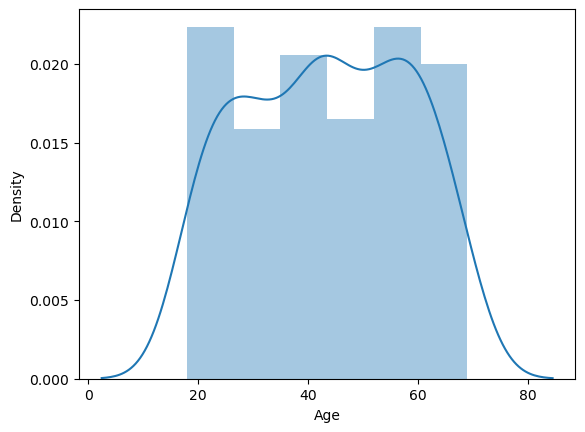

In [63]:
for col in df.select_dtypes('int64'):
    plt.figure()
    sns.distplot(df[col])
    

In [64]:
for col in df.select_dtypes('object'):
    print(f'{col:-<50} {df[col].unique()}')

Gender-------------------------------------------- ['Female' 'Male' nan]
Helmet_Used--------------------------------------- ['No' 'Yes']
Seatbelt_Used------------------------------------- ['No' 'Yes']
Survived------------------------------------------ ['survived' 'not_survived']


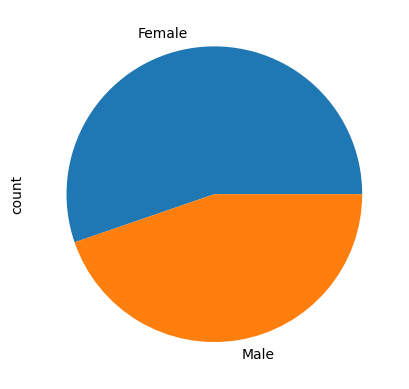

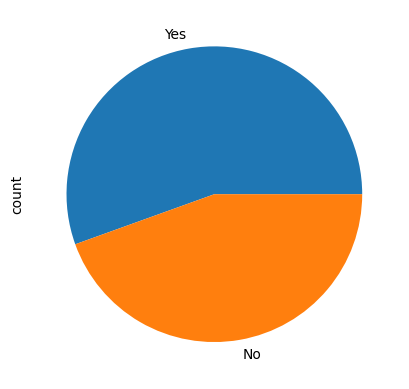

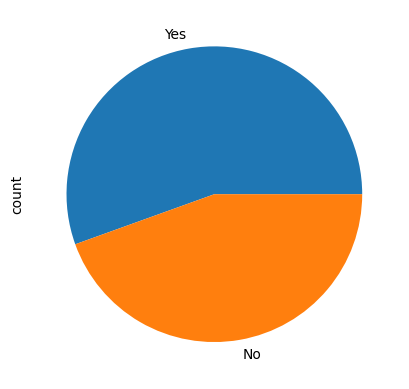

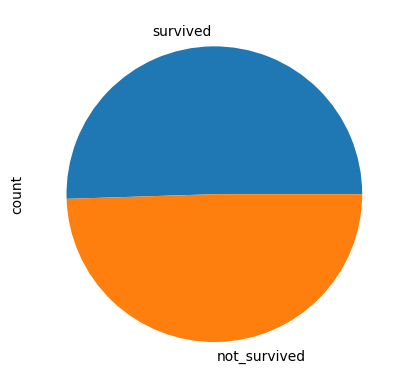

In [65]:
for col in df.select_dtypes('object'):
    plt.figure()
    df[col].value_counts().plot.pie()
    plt.show()

# Relations variables/ target

# creation de sous ensembles

In [66]:
survived = df[df['Survived'] == 'survived']
not_survived = df[df['Survived'] == 'not_survived']

C:\Users\DELL LATITUDE\AppData\Local\Temp\ipykernel_11784\1288812705.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(survived[col], label = 'survived')
C:\Users\DELL LATITUDE\AppData\Local\Temp\ipykernel_11784\1288812705.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(not_survived[col], 

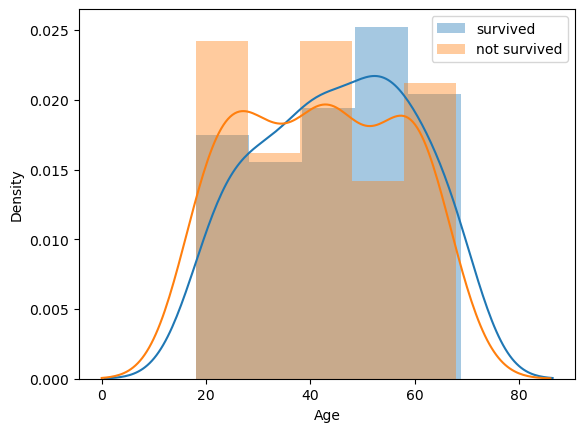

In [67]:
for col in df.select_dtypes('int'):
    plt.figure()
    sns.distplot(survived[col], label = 'survived')
    sns.distplot(not_survived[col], label = 'not survived')
    plt.legend()
    plt.show()

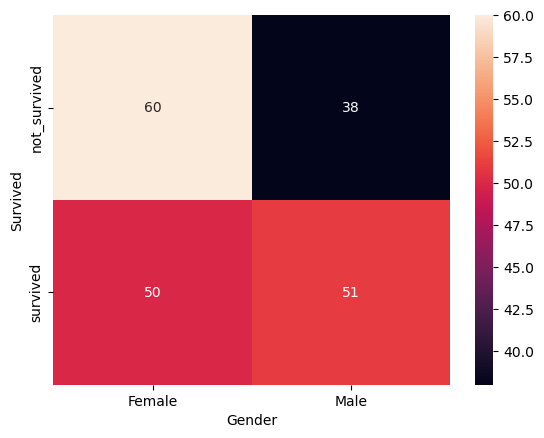

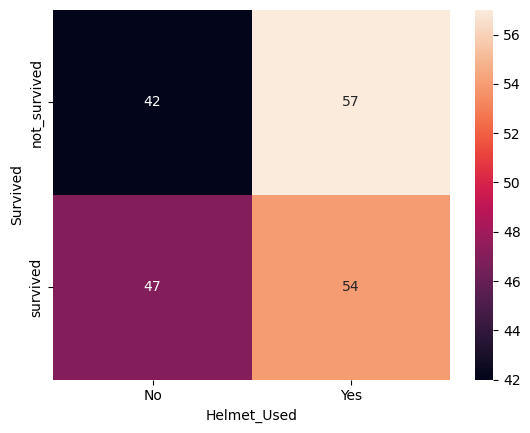

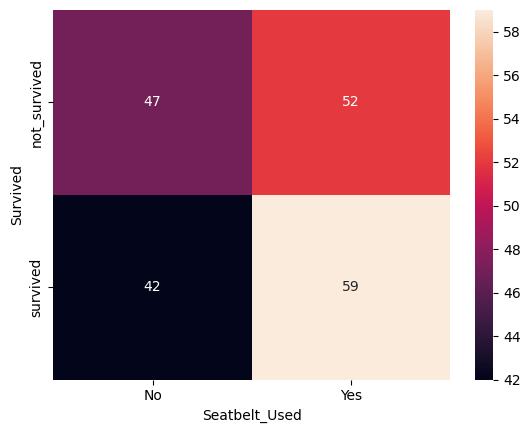

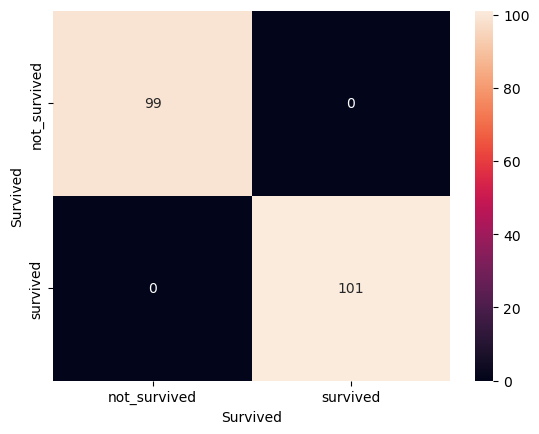

In [68]:
for col in df.select_dtypes('object'):
    plt.figure()
    sns.heatmap(pd.crosstab(df['Survived'], df[col]), annot = True, fmt = 'd')

# relation variable / variable

<Axes: >

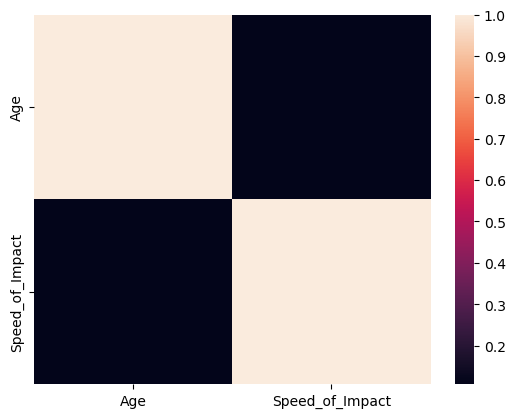

In [69]:
sns.heatmap(df.select_dtypes(exclude = 'object').corr())

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

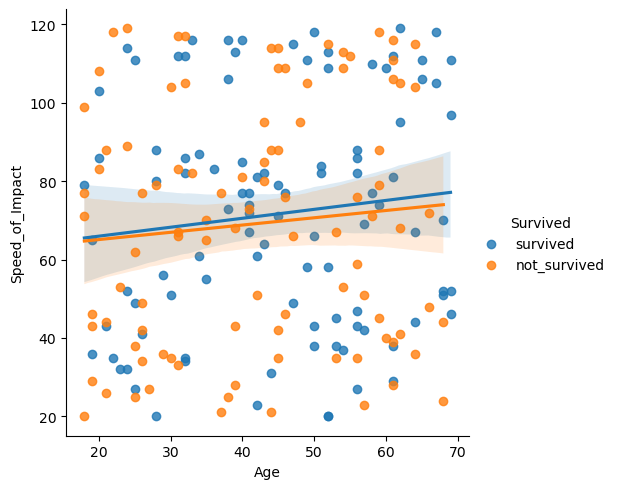

In [70]:
for col in df.select_dtypes(exclude = ['object', 'int']):
    plt.figure()
    sns.lmplot(x = 'Age', y =col,
               hue = 'Survived', data = df)

In [71]:
from scipy.stats import ttest_ind

In [72]:
survived.shape

(101, 6)

In [73]:
not_survived.shape

(99, 6)

In [74]:
balanced_sample = survived.sample(not_survived.shape[0])

In [75]:
def t_test(col):
    alpha = 0.05
    stat, p = ttest_ind(balanced_sample.dropna(),
                        not_survived.dropna())
    if p<alpha:
        return 'H0 rejette'
    else:
        return 0

# preprocessing
## TrainTest- Nettoyage-Encodage

In [76]:
from sklearn.model_selection import train_test_split
trainset, testset = train_test_split(df, test_size = 0.2, random_state = 0)

In [77]:
testset['Survived'].value_counts()

Survived
survived        21
not_survived    19
Name: count, dtype: int64

In [78]:
trainset['Survived'].value_counts()

Survived
survived        80
not_survived    80
Name: count, dtype: int64

In [79]:
# encodage
from sklearn.preprocessing import OneHotEncoder
def One_hot_encode(df):
    cat_cols = df.select_dtypes('object').columns.tolist()
    
    if not cat_cols:
        return df.copy()
    
    ohe = OneHotEncoder(sparse=False, drop='first')
    
    encoded_array = ohe.fit_transform(df[cat_cols])
    
    encoded_cols = ohe.get_feature_names_out(cat_cols)
    
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index = df.index)
    
    df = df.drop(columns=cat_cols)
    df  = pd.concat([df, df_encoded], axis = 1)
    
    return df

In [80]:

def imputation(df):
    
    df = df.dropna(axis = 0)
    
    return df
    

In [81]:
def preprocessing(df):
    
    df = encodage(df)
    df = imputation(df)
    
    X = df.drop('Survived', axis = 1)
    y = df['Survived']
    
    print(y.value_counts())
    
    return X, y

In [82]:
X_train, Y_train = preprocessing(trainset)

Survived
1    79
0    77
Name: count, dtype: int64


In [83]:
X_test, Y_test = preprocessing(testset)
Y_train = Y_train.astype(int)
Y_test = Y_test.astype(int)

Survived
1    21
0    19
Name: count, dtype: int64


# modelling

In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, recall_score, confusion_matrix,classification_report
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif


preprocessor = make_pipeline (PolynomialFeatures(2), SelectKBest(f_classif, k='all'))

In [85]:
def evaluation(model):
    
    model.fit(X_train, Y_train)
    ypred = model.predict(X_test)
    
    print(confusion_matrix(Y_test, ypred))
    print(classification_report(Y_test, ypred))
    
    N, train_score, val_score = learning_curve(model, X_train, Y_train,
                                              cv=4, scoring='f1',
                                               train_sizes=np.linspace(0.1, 1,10))
    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1),label='train score')
    plt.plot(N, val_score.mean(axis=1),label='validation score')

RandomForest


C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[[11  8]
 [12  9]]
              precision    recall  f1-score   support

           0       0.48      0.58      0.52        19
           1       0.53      0.43      0.47        21

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.51      0.50      0.50        40



C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

...

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

KNN
[[10  9]
 [13  8]]
              precision    recall  f1-score   support

           0       0.43      0.53      0.48        19
           1       0.47      0.38      0.42        21

    accuracy                           0.45        40
   macro avg       0.45      0.45      0.45        40
weighted avg       0.45      0.45      0.45        40



C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

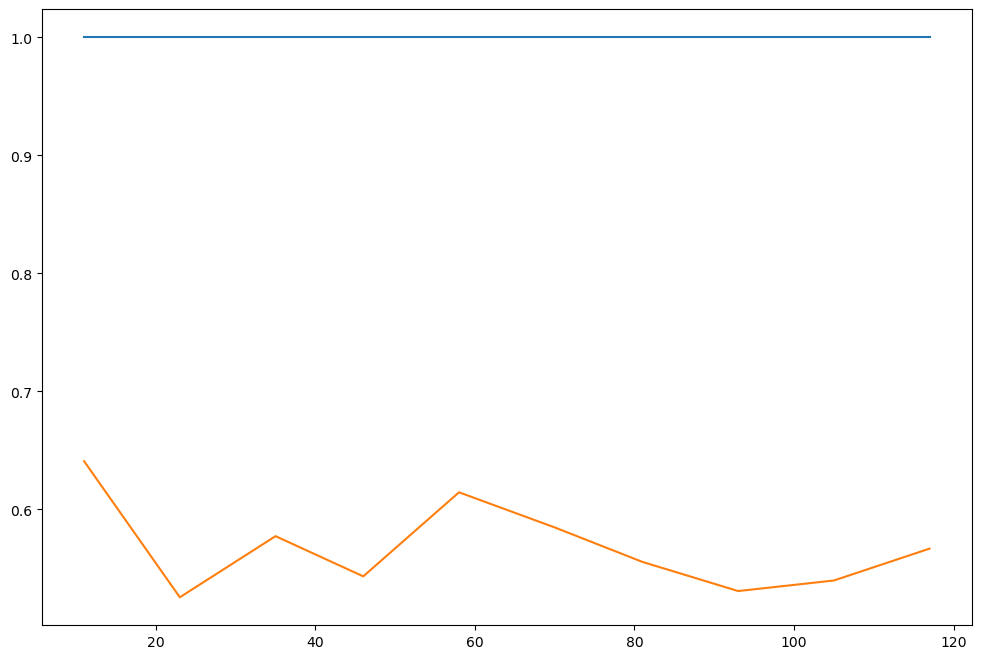

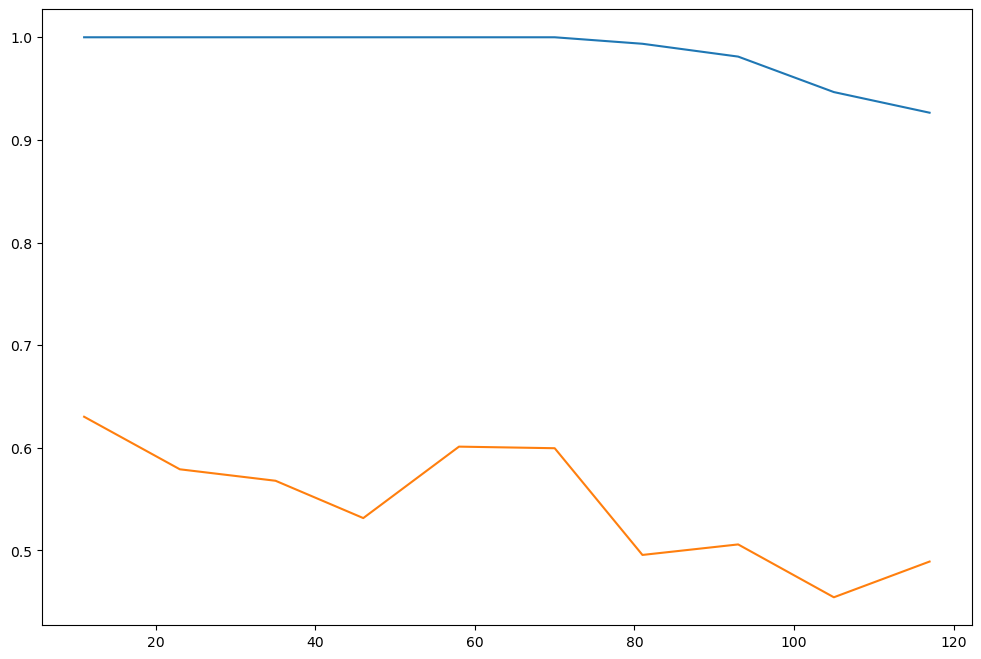

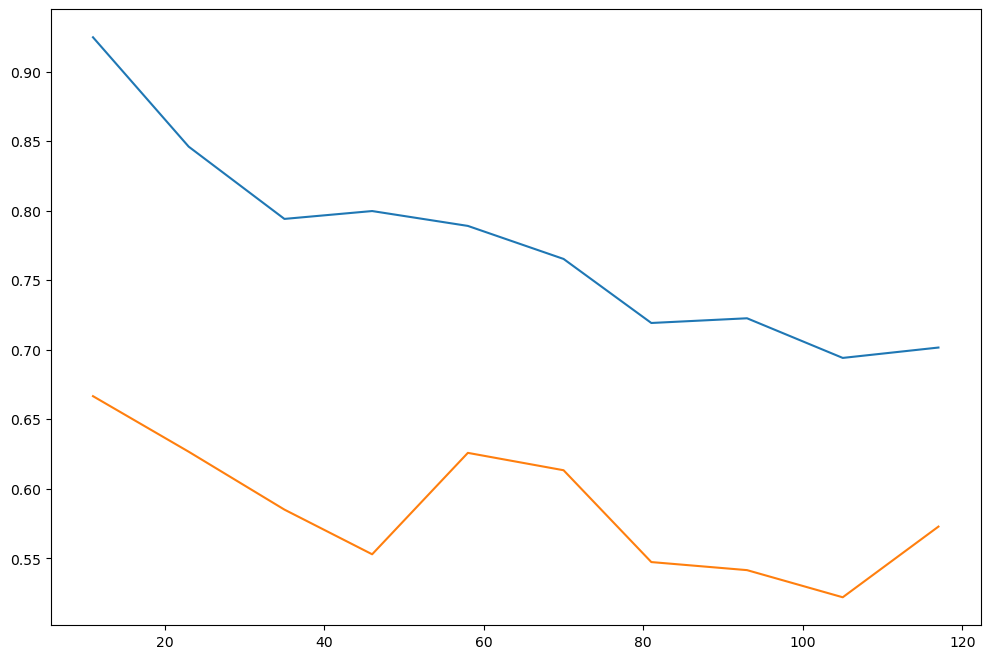

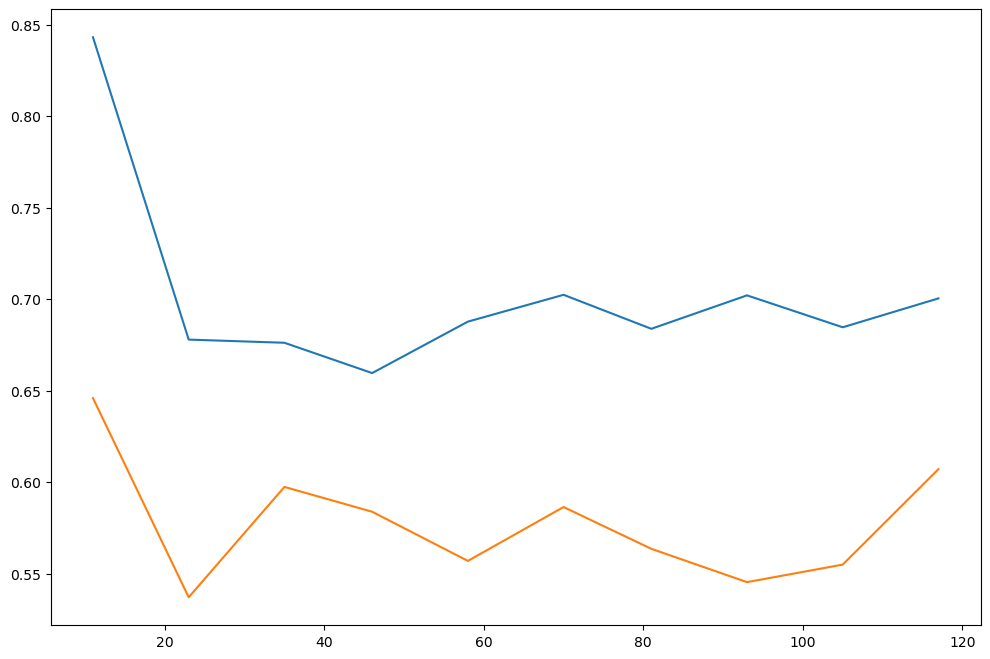

In [86]:
RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
AdaBoost = make_pipeline(preprocessor, AdaBoostClassifier(random_state=0))
SVM = make_pipeline(preprocessor, StandardScaler(), SVC(random_state=0))
KNN = make_pipeline(preprocessor, StandardScaler(), KNeighborsClassifier())

list_of_model = {
    'RandomForest' : RandomForest,
    'AdaBoost' : AdaBoost,
    'SVM': SVM,
    'KNN': KNN}

for name, model in list_of_model.items():
    print(name)
    evaluation(model)

In [87]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [88]:
print(AdaBoost)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                                 ('selectkbest', SelectKBest(k='all'))])),
                ('adaboostclassifier', AdaBoostClassifier(random_state=0))])


In [89]:
hyper_params = {
    'svc__gamma':[1e-3, 1e-4],
    'svc__C':[1, 10, 100, 1000],
    'pipeline__selectkbest__k': range(1, 5),
    'pipeline__polynomialfeatures__degree':[2,3,4]
}

In [91]:
grid = RandomizedSearchCV(SVM, hyper_params, scoring='recall', cv=4,
                   n_iter =20)
grid.fit(X_train, Y_train)

print(grid.best_params_)

y_pred = grid.predict(X_test)

print(classification_report(Y_test, y_pred))


C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

{'svc__gamma': 0.0001, 'svc__C': 1, 'pipeline__selectkbest__k': 2, 'pipeline__polynomialfeatures__degree': 3}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.53      1.00      0.69        21

    accuracy                           0.53        40
   macro avg       0.26      0.50      0.34        40
weighted avg       0.28      0.53      0.36        40



C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

[[ 0 19]
 [ 0 21]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.53      1.00      0.69        21

    accuracy                           0.53        40
   macro avg       0.26      0.50      0.34        40
weighted avg       0.28      0.53      0.36        40



C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\DELL LATITUDE\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." %

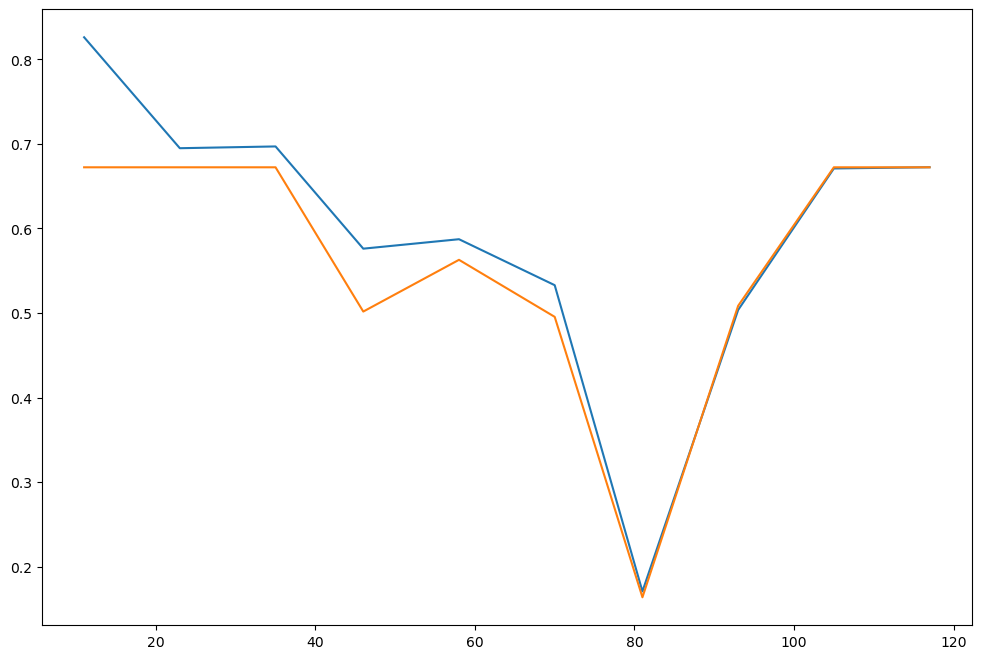

In [92]:
evaluation(grid.best_estimator_)

In [93]:
from sklearn.metrics import precision_recall_curve
precision, recall, threshold = precision_recall_curve(Y_test, grid.best_estimator_.decision_function(X_test))

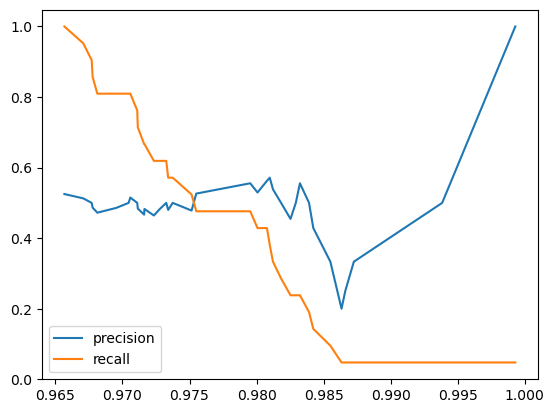

In [94]:
plt.plot(threshold,precision[:-1], label='precision')
plt.plot(threshold,recall[:-1], label='recall')
plt.legend()

In [95]:
def model_final(model, X, threshold = 0):
    return model.decision_function(X) > threshold

In [100]:
y_pred = model_final(grid.best_estimator_, X_test, threshold = 0.97)
from sklearn.metrics import recall_score
recall_score(Y_test, y_pred)

0.8095238095238095

In [101]:
f1_score(Y_test, y_pred)

0.6181818181818182

In [102]:
confusion_matrix(Y_test, y_pred)

array([[ 2, 17],
       [ 4, 17]], dtype=int64)

In [103]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.11      0.16        19
           1       0.50      0.81      0.62        21

    accuracy                           0.48        40
   macro avg       0.42      0.46      0.39        40
weighted avg       0.42      0.47      0.40        40



In [52]:
df['Survived'].value_counts()

Survived
survived        101
not_survived     99
Name: count, dtype: int64